In [2]:
import os
from os import path
print(os.getcwd())

import sys
print(sys.version)

import cv2

from RABiTPy import Capture, Identify, Stats, Tracker
from RABiTPy.constants import AvailableOperations, AvailableProps, PropsThreshold 
%matplotlib inline

C:\Users\mcwil\anaconda_projects\82b193c3-02b5-45a5-b486-9a18ed0be078
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [3]:
'''
capturing data
'''

capture = Capture("./glidingbead")
capture.load_video("glidingbead.avi")

frames = capture.process_video_into_frames(pixel_scale_factor=0.166666, scale_units='um', is_store_video_frames=True, store_images_path='frames')


---------- Video Stats ----------
Video Frame Width: 320
Video Frame Height: 220
Frame Rate: 29.97002997002997 FPS
Total Frames: 209.0 frames
Video Duration (s): 6.97
---------------------------------
Video file loaded successfully: ./glidingbead\glidingbead.avi


Frame capture progress: 100%|██████████| 209/209 [00:02<00:00, 93.87it/s]

209 frame(s) captured successfully for the video FPS: 29.97002997002997 to the folder: ./glidingbead\frames
Processed video into frames successfully with pixel scale factor: 0.166666 um


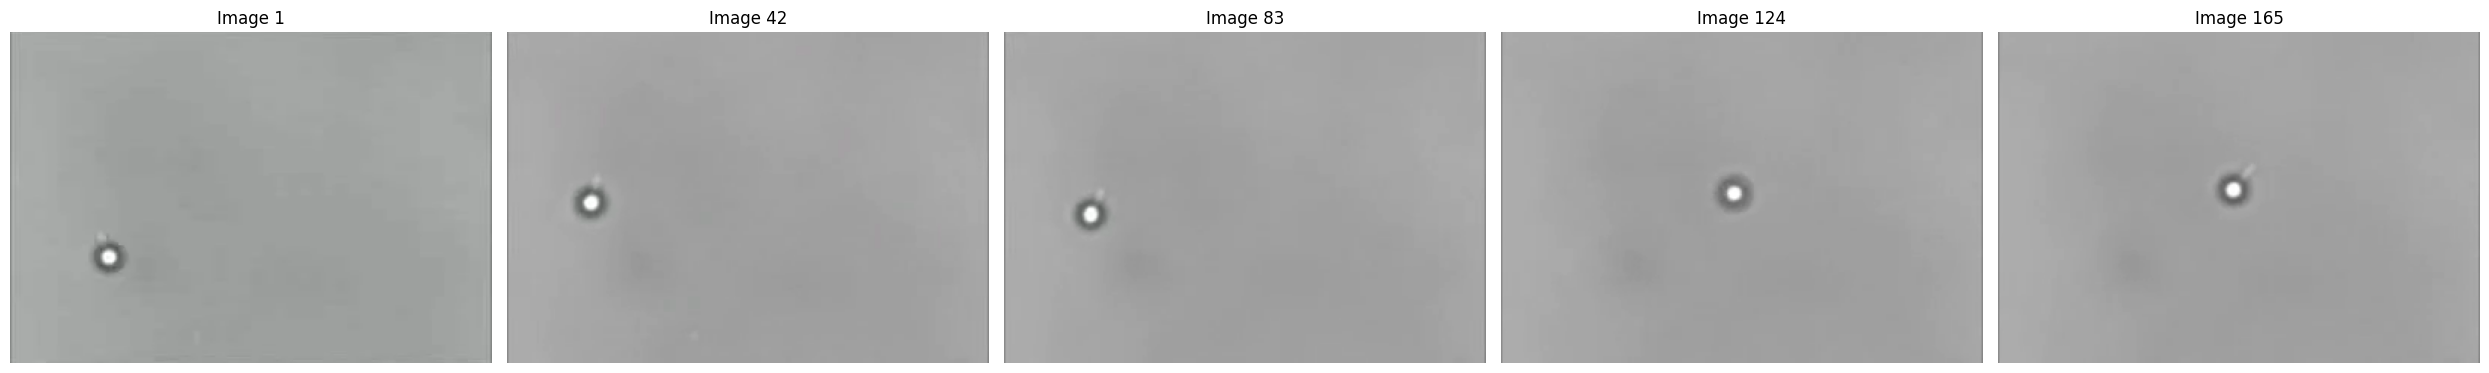

Applying Gaussian adaptive thresholding: 100%|██████████| 209/209 [00:00<00:00, 703.82it/s]


Gaussian adaptive thresholding applied successfully.
NOTE: If dark objects are displayed over a light background, set 'is_color_inverse' to True and redo the thresholding to correct it before proceeding to the next step.


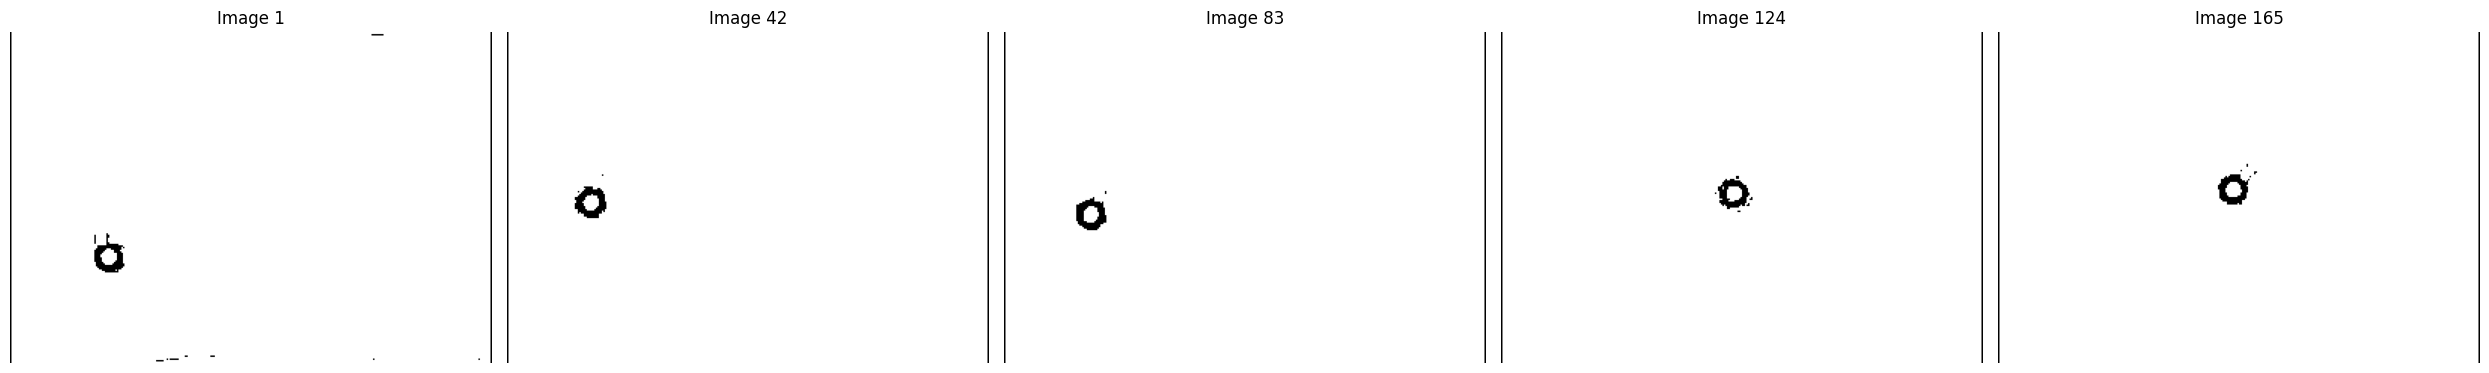

Generating region properties: 100%|██████████| 209/209 [00:02<00:00, 90.27it/s]

Region properties generated successfully.


,label,area,centroid_x,centroid_y,major_axis_length,minor_axis_length,frame
0,1,69601.0,109.293444,159.948550,367.170893,254.299434,1
1,2,89.0,149.213483,65.202247,10.829819,10.514031,1
2,3,1.0,158.000000,70.000000,0.000000,0.000000,1
3,1,69599.0,109.297188,159.955976,367.152247,254.317803,2
4,2,90.0,148.611111,64.544444,11.434566,10.033245,2
...,...,...,...,...,...,...,...
441,2,84.0,104.000000,156.535714,10.564992,10.112631,207
442,1,69643.0,109.527347,159.512471,368.024244,254.599250,208
443,2,84.0,104.000000,156.535714,10.564992,10.112631,208
444,1,69643.0,109.527347,159.512471,368.024244,254.599250,209


In [4]:
'''
thresholding
'''
identify = Identify(capture_frame_object=capture)

#display original frames
identify.show_frames(images_to_show_count=5, images_per_row=5, use_gray_cmap=True)

identify.apply_gaussian_adaptive_thresholding(block_size = 11, c = 5, is_color_inverse = False, is_update_frames = True);
identify.show_frames(images_to_show_count=5, images_per_row=5, use_gray_cmap=True)

view_props = [
    AvailableProps.LABEL, # Label is mandatory for the region properties
    AvailableProps.AREA,
    AvailableProps.CENTROID,
    AvailableProps.MAJOR_AXIS_LENGTH,
    AvailableProps.MINOR_AXIS_LENGTH
]

# Generate region properties for the frames and store them in a DataFrame
region_props_df = identify.generate_region_props_to_dataframe(view_props)

# Display the DataFrame
region_props_df

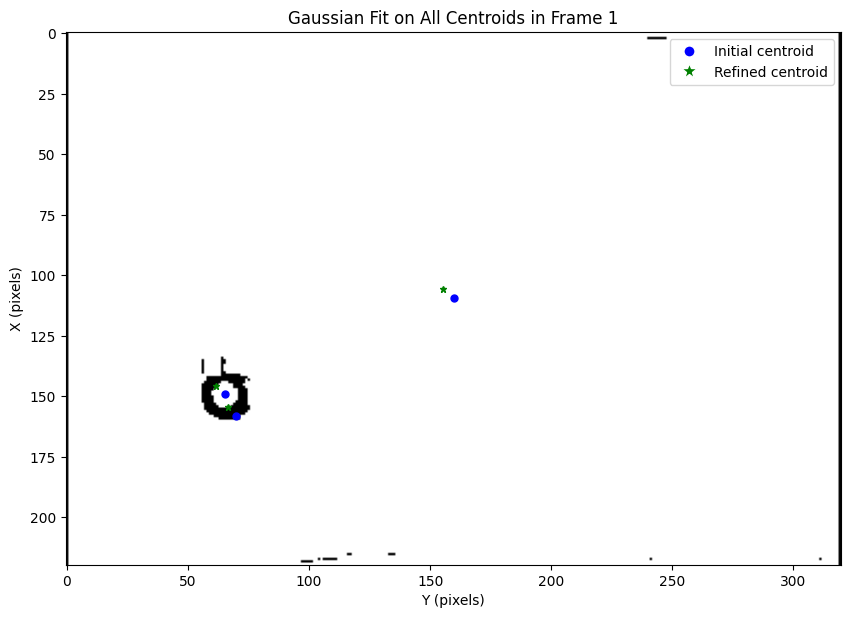

Updating centroids: 100%|██████████| 209/209 [00:00<00:00, 381.82it/s]

Centroids optimized successfully using Gaussian fit.
Filters applied successfully.


In [5]:
identify.visualize_gaussian_fit_on_a_frame(frame_index=1, fit_window=7)
identify.optimize_centroids_using_gaussian_fit(fit_window=7)

from typing import List

# Apply filters on region properties
props_threshold: List[PropsThreshold] = [
    {
        'property': AvailableProps.AREA,               # Property to filter on
        'operation': AvailableOperations.GREATER_THAN, # Operation to perform
        'value': 20                                    # Value to compare with
    }
]

# Apply filters on the generated region properties
filtered_df = identify.apply_filters_on_region_props(props_threshold, is_update_dataframes = True)

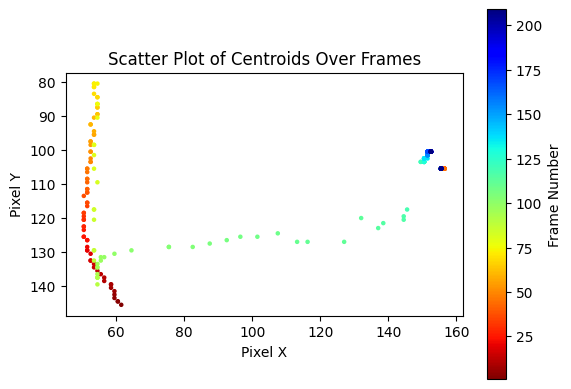

Identified objects saved successfully to path:  ./glidingbead\identified_objects.csv


In [6]:
identify.plot_centroids(show_time=True)

# Save identified objects to CSV
identify.save_identified_objects_to_csv(output_file_name='identified_objects')

Frame 209: 2 trajectories present.
Successfully linked 2 particles.
After filtering based on min 10 frames: 2 unique particles
After filtering based on min 2 displacement filtering: 1 unique particles
Linked dataframes saved to ./glidingbead\linked_particle_inverse_gliding.csv


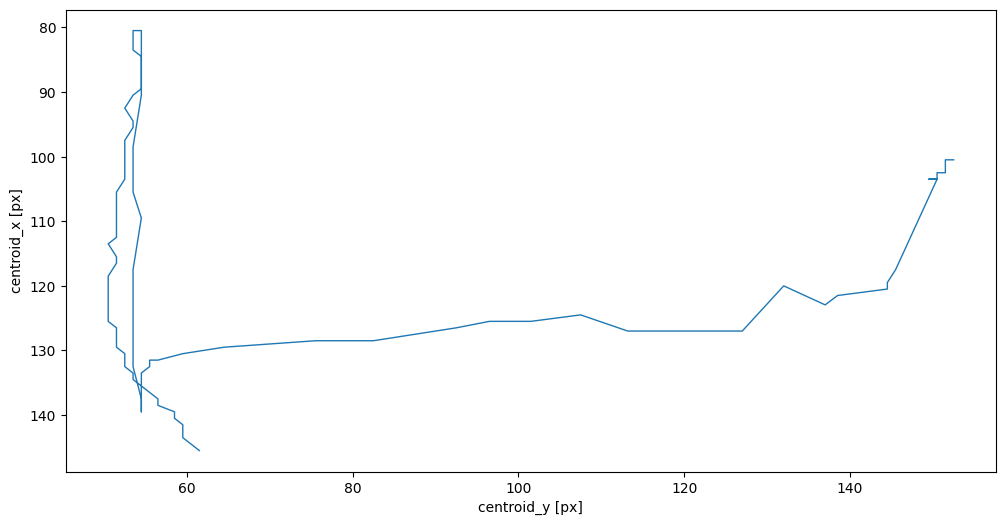

Trajectories plotted successfully.


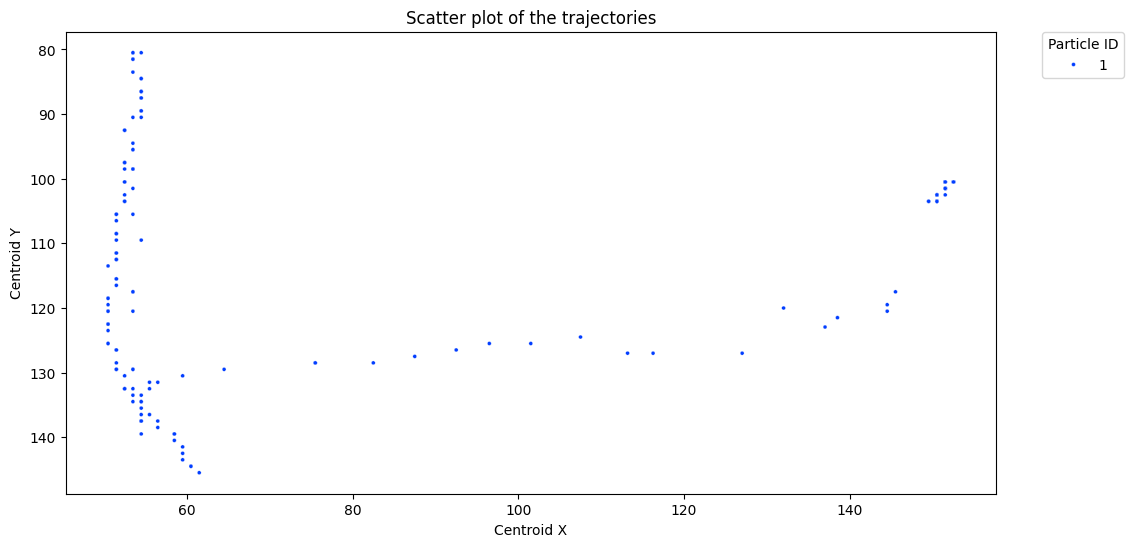

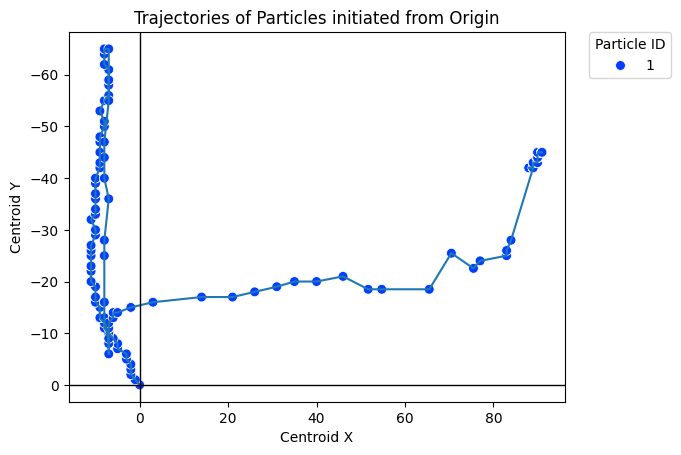

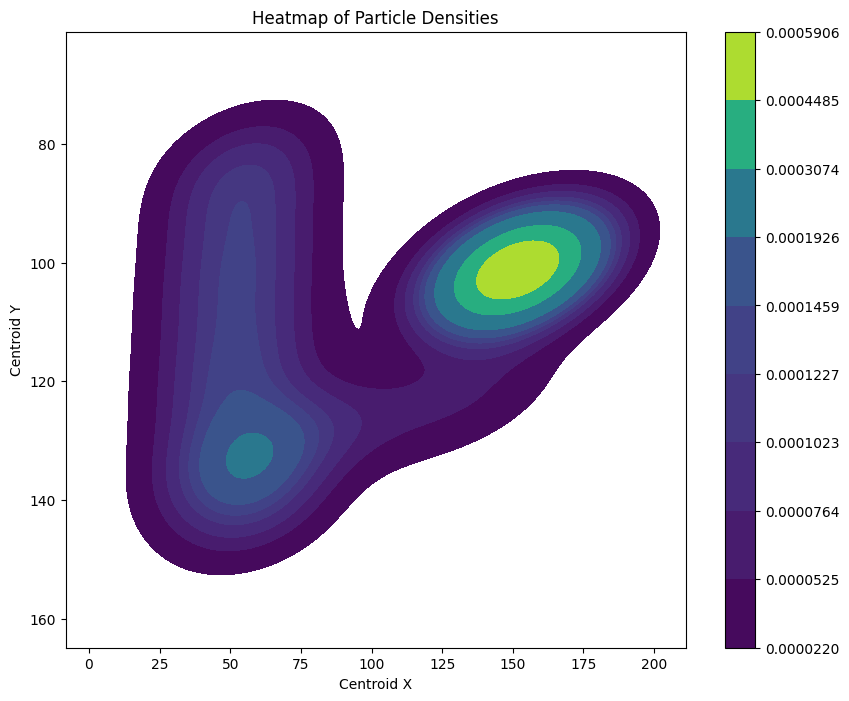

Overlaying Tracks on Video: 100%|██████████| 209/209 [00:00<00:00, 703.19it/s]

Processed video with overlaid tracks saved to ./glidingbead\gliding_inverse_tracks_overlaid.avi


In [7]:
tracker = Tracker(identify_object=identify)

tracker.link_particles(max_distance=50, max_memory=50, position_columns=['centroid_x', 'centroid_y'])

# Filter particles to retain only those with a minimum number of frames and displacement
tracker.filter_particles(min_frames=10, min_displacement=2, is_update_particles=True)
tracker.save_linked_dataframes(output_file_name='linked_particle_inverse_gliding')

tracker.plot_trajectories_using_trackpy()
tracker.sort_and_plot_scatter_of_trajectories()
tracker.visualize_particle_trajectories_from_origin()
tracker.visualize_particle_heatmap()

tracker.overlay_tracks_on_video(
    output_video_filename="gliding_inverse_tracks_overlaid.avi",
    colormap_name="viridis",
    show_labels=True,
    font_scale=1.2
)

Total unique particles: 1


Calculating Speed:   0%|          | 0/1 [00:00<?, ?it/s]

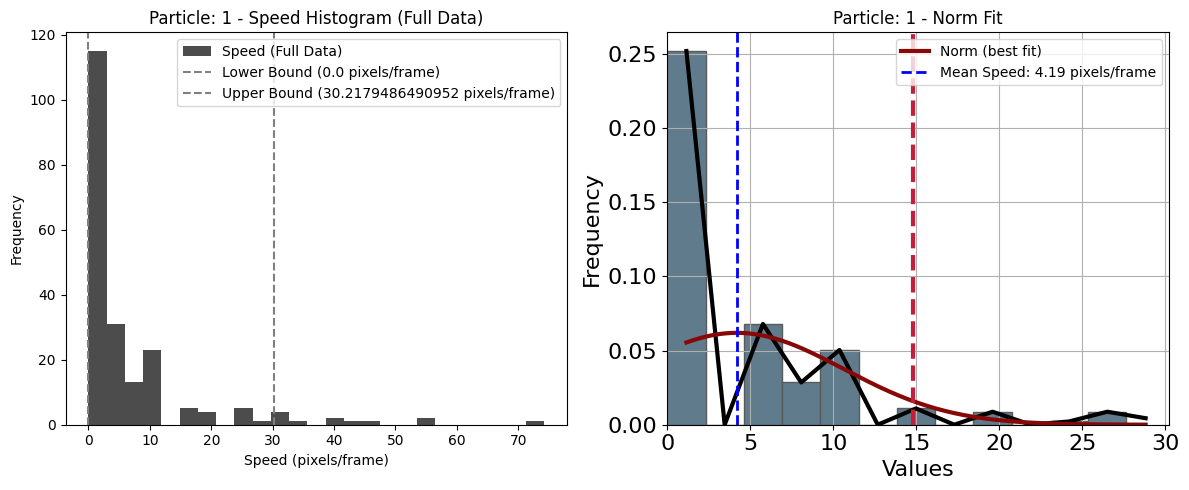

Calculating Speed: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


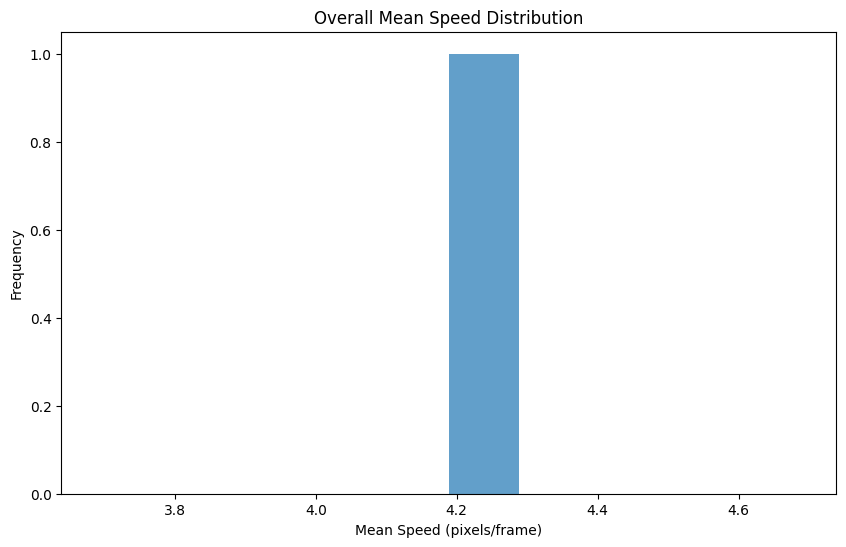

Mean speeds saved to ./glidingbead\mean_speeds.csv


In [8]:
stats = Stats(tracker_object=tracker)

# Calculate the speed and plot the mean of the distribution
stats.calculate_speed_and_plot_mean(distribution_type='norm', ci_range=(5, 95), bin_size=25, speed_unit='pixels/frame')

stats.plot_overall_mean_speed_distribution(bins=10, speed_unit='(pixels/frame)')

# Save the mean speeds to a CSV file
stats.save_mean_speeds(filename='mean_speeds')